# Ch2 頻域分析(The Frequency Domain)

**對應原書**:Chapter 2 & 3(頻域方法)
**軟體替代**:ModelQ 的解析 Bode → python-control;ModelQ 的 **DSA(動態訊號分析儀)** → chirp 激發 + `scipy.signal` 交叉頻譜量測

## 學習目標
1. 讀懂開迴路 Bode 圖,並求出增益邊限(GM)與相位邊限(PM)。
2. 理解閉迴路頻寬(bandwidth)與峰值(peaking)。
3. 用「量測」方式(DSA)得到頻率響應,並與解析解交叉驗證。

## 實驗系統:速度迴路
- 受控體:剛體慣量 $P(s) = \dfrac{1}{Js+b}$,$J=0.002\,\mathrm{kg\,m^2}$、$b=0.01$
- 控制器:PI $C(s) = 0.5 + 5/s$

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

開迴路邊限: {'gm_db': inf, 'pm_deg': 88.85583671587517, 'f_gm_hz': nan, 'f_pm_hz': 39.81256378896919}
閉迴路 -3dB 頻寬: 40.5 Hz


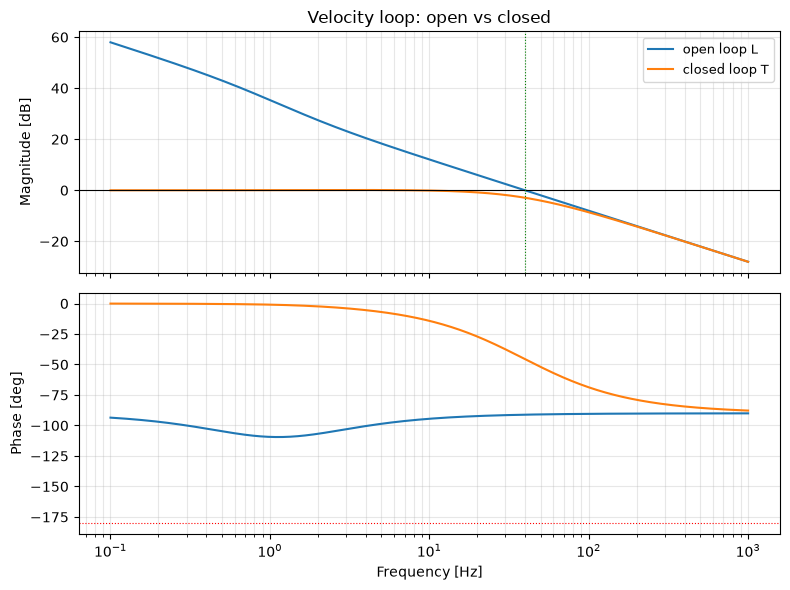

In [2]:
J, b = 0.002, 0.01
P = inertia(J=J, b=b)
C = pi(kp=0.5, ki=5.0)
L = C * P                 # 開迴路
T = closed_loop(C, P)     # 閉迴路

m = margins(L)
bw = bandwidth_hz(T)
print('開迴路邊限:', m)
print(f'閉迴路 -3dB 頻寬: {bw:.1f} Hz')

f = np.logspace(-1, 3, 600)
fig, (axm, axp) = bode_compare([('open loop L', L), ('closed loop T', T)], f_hz=f,
                               title='Velocity loop: open vs closed')
axm.axhline(0, color='k', lw=0.8)
axp.axhline(-180, color='r', ls=':', lw=0.8)
axm.axvline(m['f_pm_hz'], color='g', ls=':', lw=0.8)
plt.show()

## DSA 量測:用 chirp 激發閉迴路

ModelQ 的 DSA 在迴路中注入掃頻訊號、用 FFT 量測頻率響應。這裡用同樣方法:
1. 以 5 kHz 執行**離散**速度迴路(`DiscretePID` + `MotorPlant`)。
2. 速度命令 = 對數 chirp(1→300 Hz)。
3. `measure_frf()` 以 Welch 交叉頻譜估計 $T(f) = Y/R$,並回報 coherence。

量測結果應與解析閉迴路重合(高頻略有相位差 —— 那是取樣延遲,第 4 章主題)。

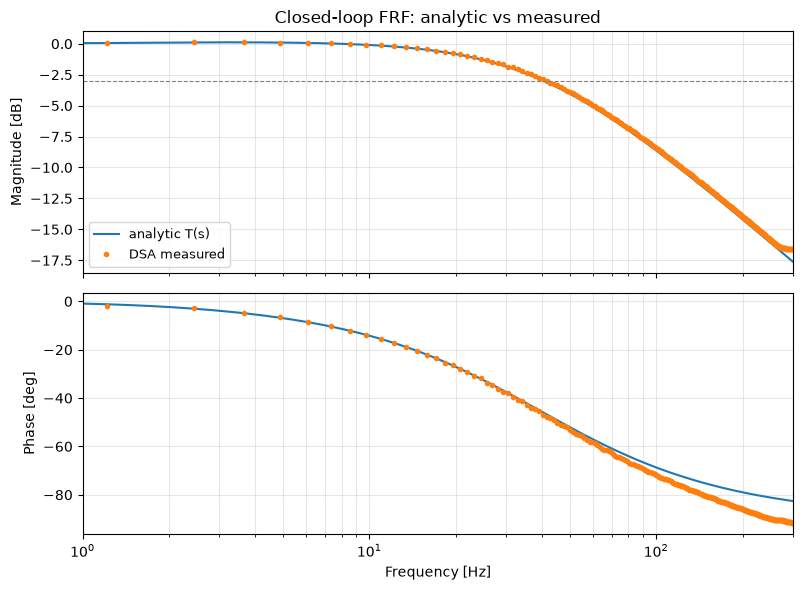

解析頻寬 40.5 Hz | DSA 量測頻寬 42.7 Hz


In [3]:
fs = 5000.0
dt = 1 / fs
tt, r = chirp_excitation(f0=1, f1=300, duration=20, fs=fs, amplitude=1.0)

plant = MotorPlant(J=J, b=b, dt=dt)
ctrl = DiscretePID(kp=0.5, ki=5.0, dt=dt)
y = np.empty_like(r)
for k, rk in enumerate(r):
    y[k] = plant.w
    u = ctrl.step(rk - plant.w)
    plant.step(u)

meas = measure_frf(r, y, fs)
good = meas['coherence'] > 0.95
meas_good = {k: v[good] for k, v in meas.items()}

fig, (axm, axp) = bode_compare([
    ('analytic T(s)', T),
    ('DSA measured', meas_good, '.'),
], f_hz=np.logspace(0, np.log10(300), 400), title='Closed-loop FRF: analytic vs measured')
axm.set_xlim(1, 300); axm.axhline(-3, color='gray', ls='--', lw=0.8)
plt.show()

# 由量測資料求 -3dB 頻寬
f_m, mag_m = meas_good['f_hz'], meas_good['mag_db']
bw_meas = float(f_m[np.nonzero(mag_m < -3)[0][0]])
print(f'解析頻寬 {bw:.1f} Hz | DSA 量測頻寬 {bw_meas:.1f} Hz')

In [4]:
# ✅ 驗證
assert 85 < m['pm_deg'] < 92          # PI 速度迴路 PM ≈ 89°
assert m['gm_db'] == np.inf           # 二階迴路相位不會到 -180°,GM 無限大
assert 35 < bw < 46                   # 頻寬 ≈ 40 Hz
assert abs(bw_meas - bw) / bw < 0.3   # DSA 量測與解析誤差 < 30%
lowf = meas_good['mag_db'][meas_good['f_hz'] < 5]
assert np.all(np.abs(lowf) < 1.0)     # 低頻 |T| ≈ 0 dB
print('Ch2 驗證通過 ✅')

Ch2 驗證通過 ✅


## 練習
1. 把 `kp` 加倍,PM 與頻寬如何變化?先預測再驗證。
2. 對**開迴路** L 做 DSA 量測(激發 = 控制器輸出上疊加 chirp,量 y/u),重繪 Bode。
3. 把 chirp 振幅縮小 100 倍再量一次,coherence 在哪些頻段變差?為什麼?
4. 用 `prbs_excitation` 取代 chirp,比較量測品質。